In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
# Upload the dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

Saving heart.csv to heart (1).csv


In [ ]:
# Display dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
print(df.duplicated().sum())

1


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.shape

(303, 14)

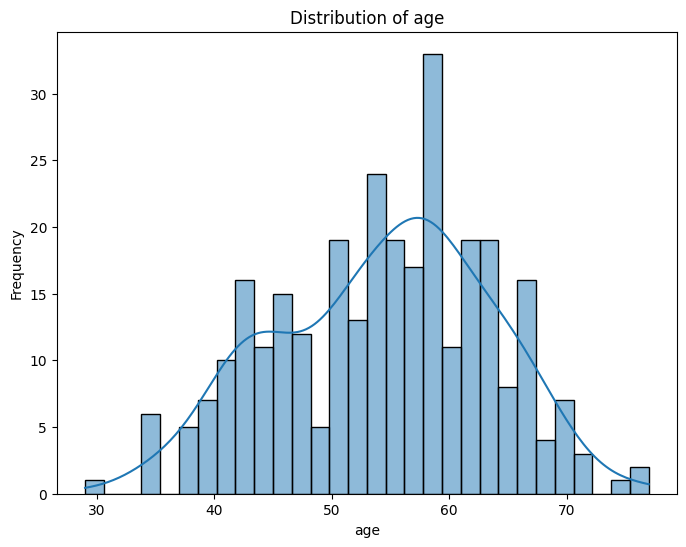

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt  # Import the pyplot module from matplotlib
import seaborn as sns

# Replace 'your_column_name' with an actual column name from your DataFrame
column_name = 'age'  # Example: Assuming 'age' is a column in your DataFrame

plt.figure(figsize=(8, 6)) # Now plt is defined and can be used
sns.histplot(df[column_name], kde=True, bins=30)
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


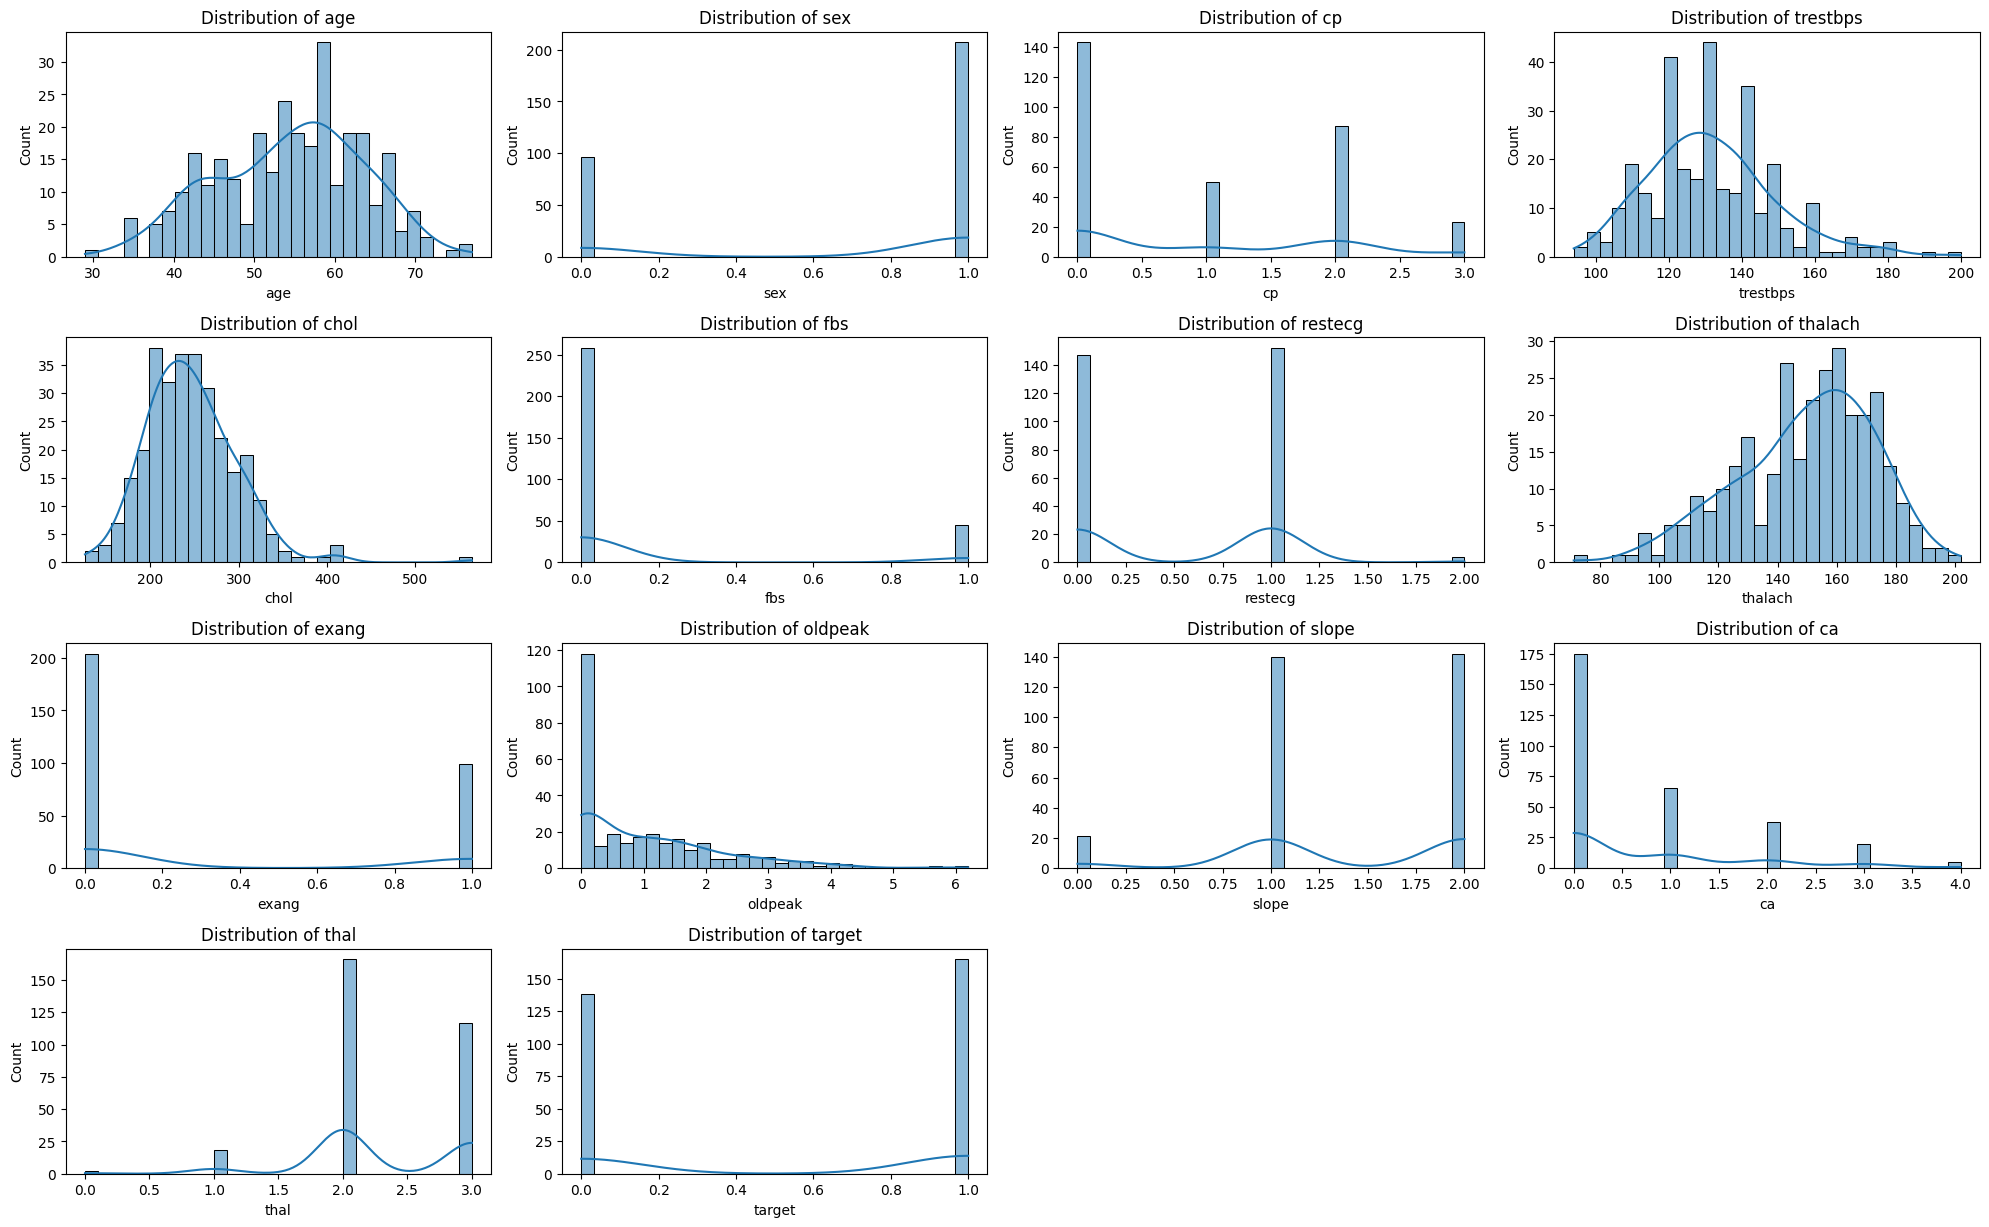

In [ ]:
# Histogram plot for numerical columns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
def plot_histograms():
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(numerical_cols):
        plt.subplot(5, 4, i + 1)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

plot_histograms()

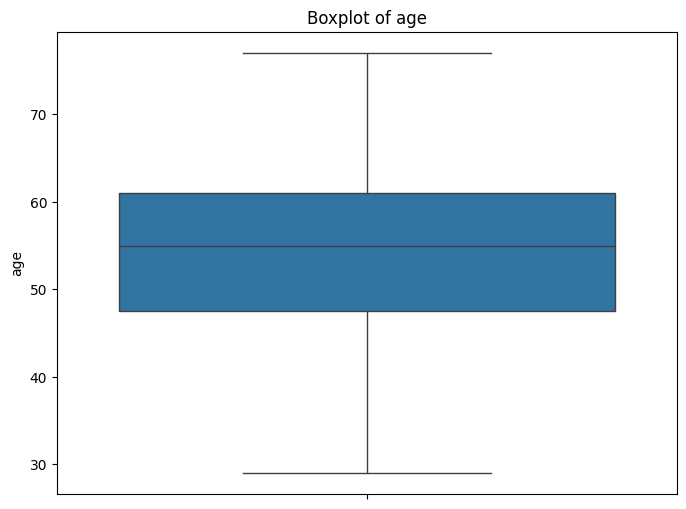

In [ ]:
# Boxplot for individual column
def plot_boxplot(column_name):
    if column_name in df.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, y=column_name)
        plt.title(f'Boxplot of {column_name}')
        plt.show()

plot_boxplot('age')

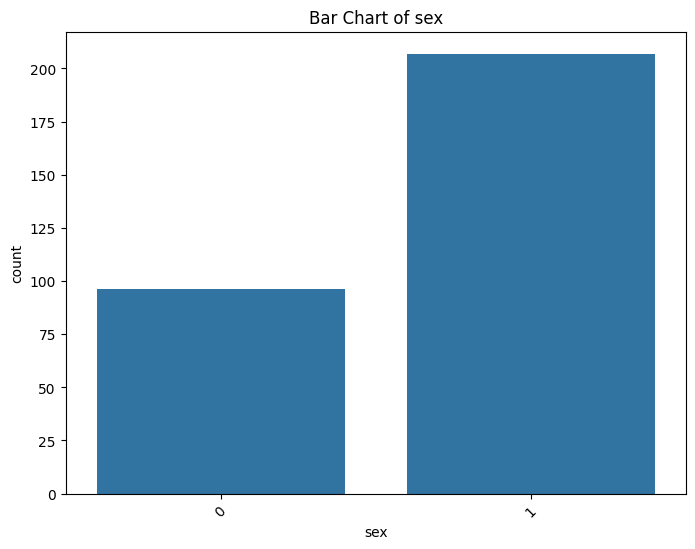

In [ ]:
# Bar chart for categorical and numerical columns
def plot_bar_chart(column_name):
    if column_name in df.columns:
        plt.figure(figsize=(8, 6))
        if df[column_name].dtype == 'object' or df[column_name].nunique() < 10:
            sns.countplot(data=df, x=column_name)
        else:
            sns.barplot(x=df[column_name].value_counts().index, y=df[column_name].value_counts().values)
        plt.title(f'Bar Chart of {column_name}')
        plt.xticks(rotation=45)
        plt.show()

plot_bar_chart('sex')

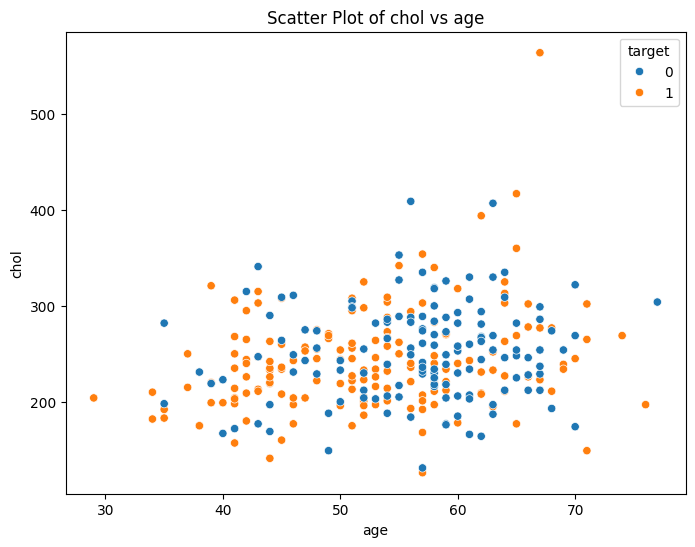

In [ ]:
# Scatter plot example
def plot_scatter(x_col, y_col, hue_col=None):
    if x_col in df.columns and y_col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=df, x=x_col, y=y_col, hue=df[hue_col] if hue_col else None)
        plt.title(f'Scatter Plot of {y_col} vs {x_col}')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.show()

plot_scatter('age', 'chol', 'target')

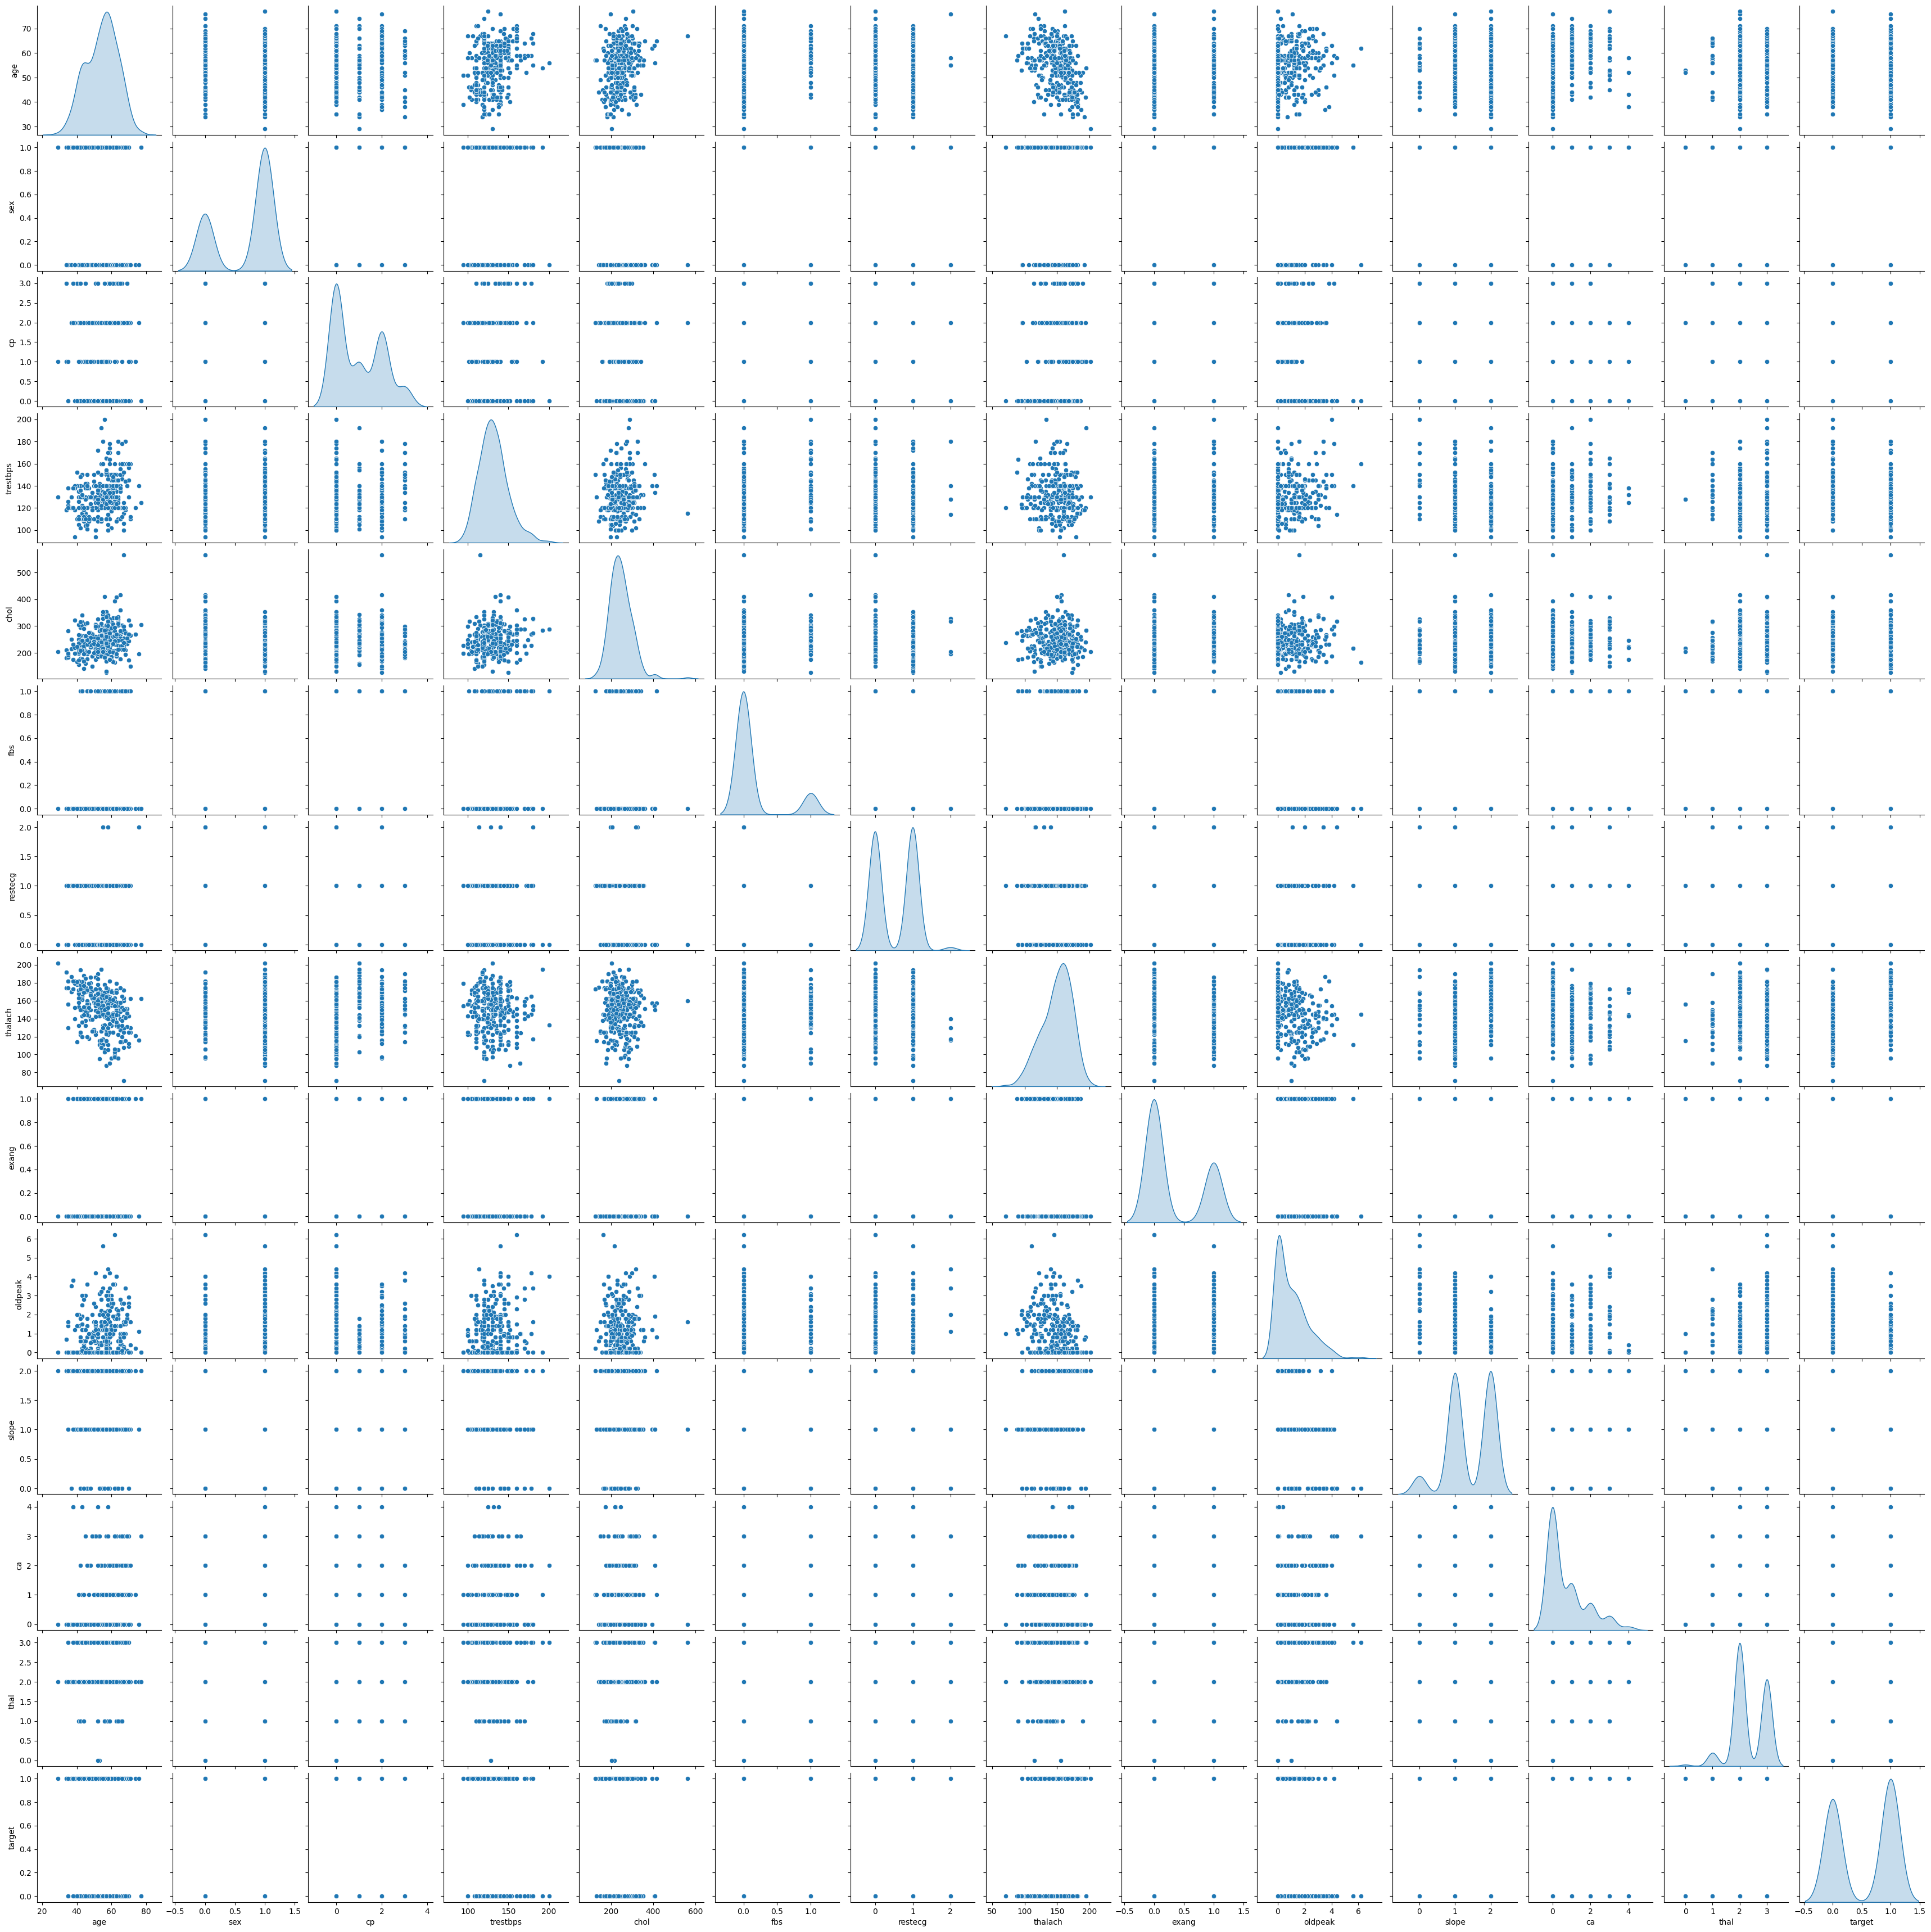

In [ ]:
# Pairplot
def plot_pairplot():
    sns.pairplot(df, diag_kind='kde')
    plt.show()

plot_pairplot()

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Display the modified DataFrame
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [ ]:
# Separate Features and Target Column
X = df.drop(columns=['target'])  # Features
y = df['target']  # Target variable
print(X)
print(y)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Assuming X and y are your features and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data

# Scaling Features (Min-Max Scaling)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define Classification Models
# Define Classification Models
from sklearn.linear_model import LogisticRegression
# Define Classification Models
# Define Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # ...
}

In [ ]:
model = LogisticRegression(max_iter=1000)


In [ ]:
# Import necessary libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd # Import pandas to read the data

# Assuming X and y are your features and target variable
# (Make sure X and y are defined before this)

# Assuming 'df' is your DataFrame, Load your DataFrame here if not already loaded
# For Example: If you have a CSV file named 'heart.csv', you would load it like this:
# df = pd.read_csv('heart.csv') # Replace with your file path

# If the data was uploaded using google.colab, get the path of uploaded data
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(next(iter(uploaded)))


X = df.drop(columns=['target'])  # Features
y = df['target']  # Target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data

# Scaling Features (Min-Max Scaling)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Define Classification Models
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # ...
}

results = {}
for name, clf in classifiers.items():
    print(f"\nModel: {name}")
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)



Model: Logistic Regression


Accuracy: 0.8525
F1 Score: 0.8525
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



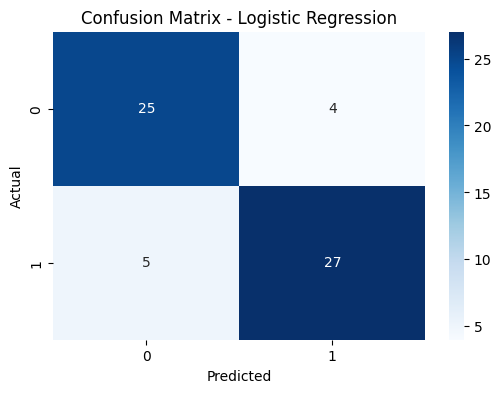

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd # Import pandas to read the data
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix # Import metrics functions
import matplotlib.pyplot as plt
import seaborn as sns


# ... (rest of your code) ...

# Train Logistic Regression
model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)  # Now accuracy_score is defined
f1 = f1_score(y_test, y_pred, average='weighted')

# ... (rest of your code) ...
# Train Logistic Regression
model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
df_clean = df.dropna() # Assign the result to df_clean
print(df_clean) # Print df_clean


     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [ ]:
categorical_cols = df_clean.select_dtypes(include=['object','category']).columns.tolist()
df_encoded1 = pd.get_dummies(df_clean, columns=categorical_cols,drop_first=True)
print(df_encoded1)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [ ]:
categorical_cols = df_clean.select_dtypes(include=['object','category']).columns.tolist()
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols,drop_first=True)
print(df_encoded)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [ ]:
numerical_cols = df_encoded.select_dtypes(include=['float64','int64']).columns.tolist()
scaler = MinMaxScaler() # Use MinMaxScaler to create a scaler object
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols]) # Fit and transform
print(df_encoded)

          age  sex        cp  trestbps      chol  fbs  restecg   thalach  \
0    0.708333  1.0  1.000000  0.481132  0.244292  1.0      0.0  0.603053   
1    0.166667  1.0  0.666667  0.339623  0.283105  0.0      0.5  0.885496   
2    0.250000  0.0  0.333333  0.339623  0.178082  0.0      0.0  0.770992   
3    0.562500  1.0  0.333333  0.245283  0.251142  0.0      0.5  0.816794   
4    0.583333  0.0  0.000000  0.245283  0.520548  0.0      0.5  0.702290   
..        ...  ...       ...       ...       ...  ...      ...       ...   
298  0.583333  0.0  0.000000  0.433962  0.262557  0.0      0.5  0.396947   
299  0.333333  1.0  1.000000  0.150943  0.315068  0.0      0.5  0.465649   
300  0.812500  1.0  0.000000  0.471698  0.152968  1.0      0.5  0.534351   
301  0.583333  1.0  0.000000  0.339623  0.011416  0.0      0.5  0.335878   
302  0.583333  0.0  0.333333  0.339623  0.251142  0.0      0.0  0.786260   

     exang   oldpeak  slope    ca      thal  target  
0      0.0  0.370968    0.0  0.00